# F1 Predictor

What we'd like to do with this project is to reliably predict podium finishers for F1 races, the first thing that we need to do however is to load in the data frames, and explore the properties a little bit. But before we do that we need to load in some of the basic libraries, and load in the data from the CSV's as well

## Loading the Data, Setting Up Libraries

We grabbed all of our data from here so far:
https://www.kaggle.com/datasets/jtrotman/formula-1-race-data

We know that the empty fields are marked with "\N" so we mark these as na values in the CSV read so that our metrics on the info reflect reality properly

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import roc_auc_score, roc_curve, auc, brier_score_loss

In [2]:
race_df = pd.read_csv("./data/races.csv", na_values="\\N")
race_df.info()
race_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1171 entries, 0 to 1170
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   raceId       1171 non-null   int64 
 1   year         1171 non-null   int64 
 2   round        1171 non-null   int64 
 3   circuitId    1171 non-null   int64 
 4   name         1171 non-null   object
 5   date         1171 non-null   object
 6   time         440 non-null    object
 7   url          1171 non-null   object
 8   fp1_date     136 non-null    object
 9   fp1_time     114 non-null    object
 10  fp2_date     118 non-null    object
 11  fp2_time     96 non-null     object
 12  fp3_date     106 non-null    object
 13  fp3_time     87 non-null     object
 14  quali_date   136 non-null    object
 15  quali_time   114 non-null    object
 16  sprint_date  30 non-null     object
 17  sprint_time  27 non-null     object
dtypes: int64(4), object(14)
memory usage: 164.8+ KB


,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
0,1,2009,1,1,Australian Grand Prix,2009-03-29,06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2009,2,2,Malaysian Grand Prix,2009-04-05,09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,2009,3,17,Chinese Grand Prix,2009-04-19,07:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Gran...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,2009,4,3,Bahrain Grand Prix,2009-04-26,12:00:00,http://en.wikipedia.org/wiki/2009_Bahrain_Gran...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,2009,5,4,Spanish Grand Prix,2009-05-10,12:00:00,http://en.wikipedia.org/wiki/2009_Spanish_Gran...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
quali_df = pd.read_csv("./data/qualifying.csv", na_values="\\N")
quali_df.info()
quali_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11036 entries, 0 to 11035
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   qualifyId      11036 non-null  int64 
 1   raceId         11036 non-null  int64 
 2   driverId       11036 non-null  int64 
 3   constructorId  11036 non-null  int64 
 4   number         11036 non-null  int64 
 5   position       11036 non-null  int64 
 6   q1             10873 non-null  object
 7   q2             6249 non-null   object
 8   q3             3893 non-null   object
dtypes: int64(6), object(3)
memory usage: 776.1+ KB


,qualifyId,raceId,driverId,constructorId,number,position,q1,q2,q3
0,1,18,1,1,22,1,1:26.572,1:25.187,1:26.714
1,2,18,9,2,4,2,1:26.103,1:25.315,1:26.869
2,3,18,5,1,23,3,1:25.664,1:25.452,1:27.079
3,4,18,13,6,2,4,1:25.994,1:25.691,1:27.178
4,5,18,2,2,3,5,1:25.960,1:25.518,1:27.236


In [4]:
res_df = pd.read_csv("./data/results.csv", na_values="\\N")
res_df.info()
res_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27304 entries, 0 to 27303
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   resultId         27304 non-null  int64  
 1   raceId           27304 non-null  int64  
 2   driverId         27304 non-null  int64  
 3   constructorId    27304 non-null  int64  
 4   number           27298 non-null  float64
 5   grid             27284 non-null  float64
 6   position         16351 non-null  float64
 7   positionText     27304 non-null  object 
 8   positionOrder    27304 non-null  int64  
 9   points           27304 non-null  float64
 10  laps             27304 non-null  int64  
 11  time             8052 non-null   object 
 12  milliseconds     8052 non-null   float64
 13  fastestLap       8769 non-null   float64
 14  rank             9027 non-null   float64
 15  fastestLapTime   8769 non-null   object 
 16  fastestLapSpeed  8252 non-null   float64
 17  statusId    

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22.0,1.0,1.0,1,1,10.0,58,1:34:50.616,5690616.0,39.0,2.0,1:27.452,218.300,1
1,2,18,2,2,3.0,5.0,2.0,2,2,8.0,58,+5.478,5696094.0,41.0,3.0,1:27.739,217.586,1
2,3,18,3,3,7.0,7.0,3.0,3,3,6.0,58,+8.163,5698779.0,41.0,5.0,1:28.090,216.719,1
3,4,18,4,4,5.0,11.0,4.0,4,4,5.0,58,+17.181,5707797.0,58.0,7.0,1:28.603,215.464,1
4,5,18,5,1,23.0,3.0,5.0,5,5,4.0,58,+18.014,5708630.0,43.0,1.0,1:27.418,218.385,1


In [5]:
constructor_df = pd.read_csv("./data/constructors.csv")
constructor_df.info()
constructor_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   constructorId   214 non-null    int64 
 1   constructorRef  214 non-null    object
 2   name            214 non-null    object
 3   nationality     214 non-null    object
 4   url             214 non-null    object
dtypes: int64(1), object(4)
memory usage: 8.5+ KB


,constructorId,constructorRef,name,nationality,url
0,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren
1,2,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber
2,3,williams,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...
3,4,renault,Renault,French,http://en.wikipedia.org/wiki/Renault_in_Formul...
4,5,toro_rosso,Toro Rosso,Italian,http://en.wikipedia.org/wiki/Scuderia_Toro_Rosso


## A Little Basic Analysis

### Constructor Dominance

Are the constructors a useful predictive factor? We can check this by seeing which teams win the most in which era

In [6]:
constructor_race_df = pd.merge(
    left=race_df[["raceId","year","round"]], 
    right=res_df[["raceId","constructorId","grid","position"]],
    how='left',
    left_on=["raceId"],
    right_on=["raceId"],
)
constructor_race_df

,raceId,year,round,constructorId,grid,position
0,1,2009,1,23.0,1.0,1.0
1,1,2009,1,23.0,2.0,2.0
2,1,2009,1,7.0,20.0,3.0
3,1,2009,1,7.0,19.0,4.0
4,1,2009,1,4.0,10.0,5.0
...,...,...,...,...,...,...
27318,1186,2026,18,NaN,NaN,NaN
27319,1187,2026,19,NaN,NaN,NaN
27320,1188,2026,20,NaN,NaN,NaN
27321,1189,2026,21,NaN,NaN,NaN


In [7]:
constructor_race_df = pd.merge(
    left=constructor_race_df, 
    right=constructor_df[["constructorId", "name"]],
    how='left',
    left_on=["constructorId"],
    right_on=["constructorId"],
)
constructor_race_df

,raceId,year,round,constructorId,grid,position,name
0,1,2009,1,23.0,1.0,1.0,Brawn
1,1,2009,1,23.0,2.0,2.0,Brawn
2,1,2009,1,7.0,20.0,3.0,Toyota
3,1,2009,1,7.0,19.0,4.0,Toyota
4,1,2009,1,4.0,10.0,5.0,Renault
...,...,...,...,...,...,...,...
27318,1186,2026,18,NaN,NaN,NaN,NaN
27319,1187,2026,19,NaN,NaN,NaN,NaN
27320,1188,2026,20,NaN,NaN,NaN,NaN
27321,1189,2026,21,NaN,NaN,NaN,NaN


In [8]:
aggregared_construictors_df = pd.DataFrame(constructor_race_df[constructor_race_df["position"] <= 3].groupby(by=["year", "name"])["raceId"].count())

pivot_constructor_df = pd.pivot_table(aggregared_construictors_df, index="year", columns=["name"], values='raceId').fillna(0)

pivot_constructor_df.loc[:, pivot_constructor_df.sum(axis=0) > 20]
pivot_constructor_df.tail()


name,Alfa Romeo,AlphaTauri,Alpine F1 Team,Arrows,Aston Martin,BAR,BMW Sauber,BRM,Benetton,Brabham,...,Talbot-Lago,Team Lotus,Toleman,Toro Rosso,Toyota,Tyrrell,Vanwall,Watson,Williams,Wolf
year,,,,,,,,,,,,,,,,,,,,,
2022,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023,0.0,0.0,2.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0
2026,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


<Axes: xlabel='name', ylabel='year'>

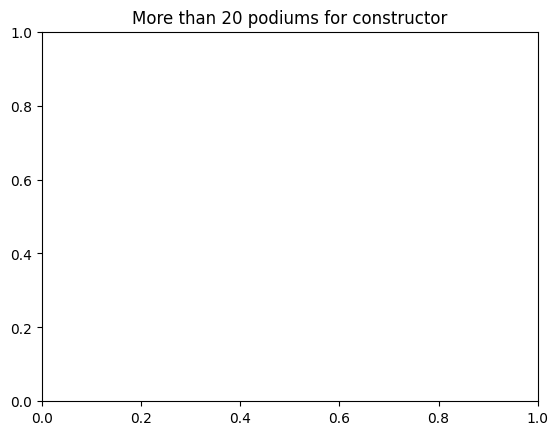

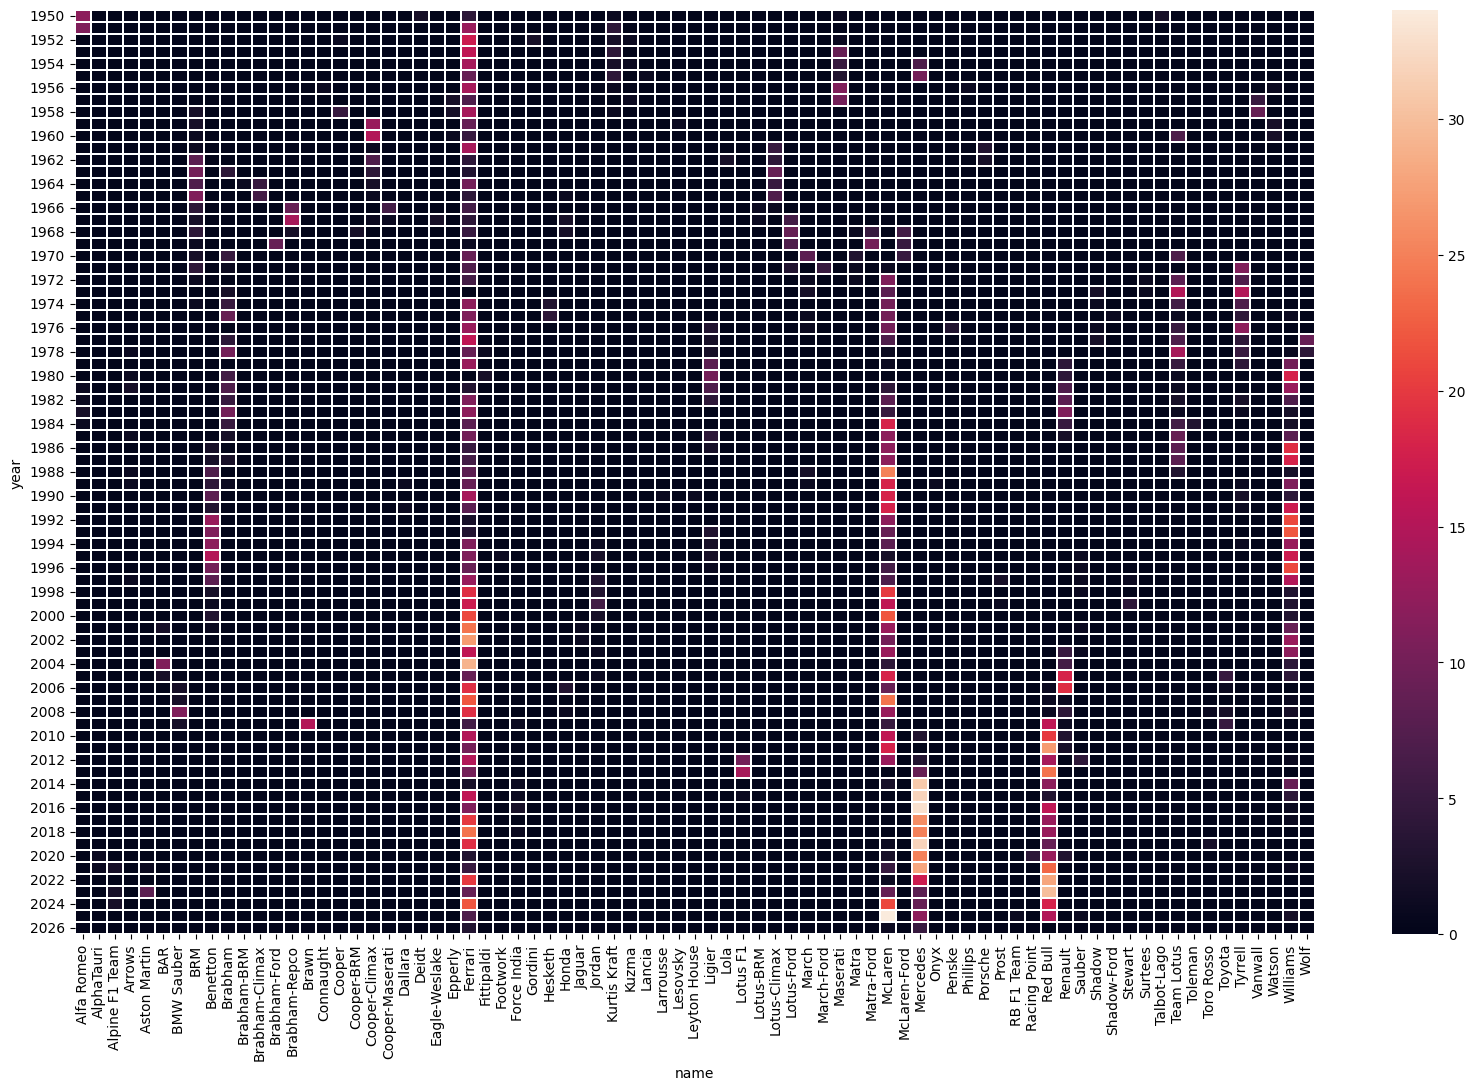

In [9]:
plt.title("More than 20 podiums for constructor")
plt.figure(figsize=(20, 12))
sns.heatmap(pivot_constructor_df, linewidths=0.1)

This is interesting, we can clearly see a pattern in certain teams e.g. ferrari, red bull, Mercedes, McLaren but other teams haven't had wins since the 1970's and so probably don't provide a ton of predictive detail. Let's try limiting it further

In [10]:
aggregared_construictors_df_2 = pd.DataFrame(constructor_race_df[constructor_race_df["position"] <= 3].groupby(by=["year", "name"])["raceId"].count())

pivot_constructor_df_2 = pd.pivot_table(aggregared_construictors_df_2, index="year", columns=["name"], values='raceId').fillna(0)

after_1990_constructor_podiums_df = pivot_constructor_df_2.loc[pivot_constructor_df_2.index > 1990]
filtered_pivot_df = pivot_constructor_df_2.loc[:, after_1990_constructor_podiums_df.sum(axis=0) > 10]
filtered_pivot_df.tail()

name,BAR,BMW Sauber,Benetton,Brawn,Ferrari,Jordan,Lotus F1,McLaren,Mercedes,Red Bull,Renault,Sauber,Toyota,Williams
year,,,,,,,,,,,,,,
2022,0.0,0.0,0.0,0.0,20.0,0.0,0.0,1.0,17.0,28.0,0.0,0.0,0.0,0.0
2023,0.0,0.0,0.0,0.0,9.0,0.0,0.0,9.0,8.0,30.0,0.0,0.0,0.0,0.0
2024,0.0,0.0,0.0,0.0,22.0,0.0,0.0,21.0,9.0,18.0,0.0,0.0,0.0,0.0
2025,0.0,0.0,0.0,0.0,7.0,0.0,0.0,34.0,12.0,15.0,0.0,1.0,0.0,2.0
2026,0.0,0.0,0.0,0.0,3.0,0.0,0.0,1.0,5.0,0.0,0.0,0.0,0.0,0.0


<Axes: title={'center': 'More than 10 podiums for constructor since 1990'}, xlabel='name', ylabel='year'>

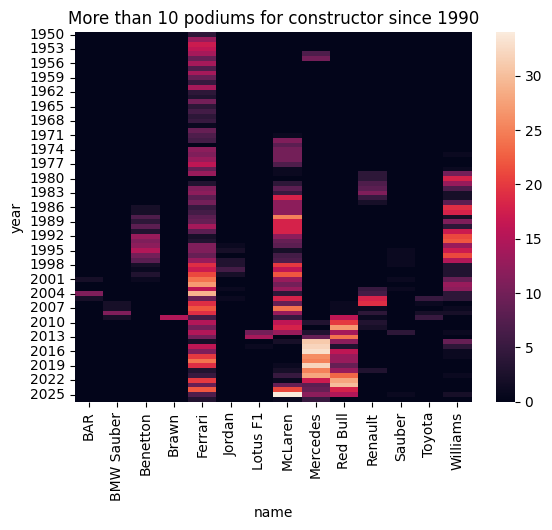

In [11]:
plt.title("More than 10 podiums for constructor since 1990")
sns.heatmap(filtered_pivot_df)

## Average Grid Vs Finish Over Time

Is overtaking harder now than it was before on average?

In [54]:
position_over_time_df = pd.merge(
    left=race_df[["raceId", "year"]],
    right=res_df[["raceId", "driverId", "grid", "position"]],
    how="left",
    on="raceId"
).dropna().reset_index(drop=True)

position_over_time_df["absPositionDifference"] = abs(position_over_time_df["grid"] - position_over_time_df["position"])

position_difference_by_year_df = pd.DataFrame(position_over_time_df.groupby("year").mean()["absPositionDifference"])

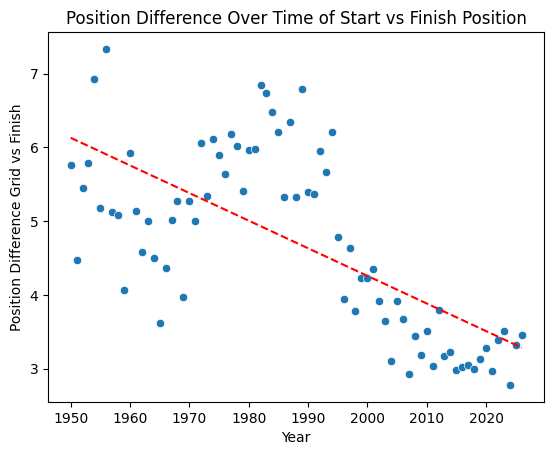

In [77]:
plt.xlabel("Year")
plt.ylabel("Position Difference Grid vs Finish")
plt.title("Position Difference Over Time of Start vs Finish Position")

trend = np.polyfit(position_difference_by_year_df.index, position_difference_by_year_df["absPositionDifference"], 1)
trendpoly = np.poly1d(trend) 

sns.scatterplot(data=position_difference_by_year_df, x=position_difference_by_year_df.index, y="absPositionDifference")
plt.plot(position_difference_by_year_df.index, trendpoly(position_difference_by_year_df.index), color="red", linestyle='dashed')

Okay great! We've got our points plotted and a trend line fitted now. We can see that there is a clear downward trend that the gaps between starting grid and finishing grid position have decreased over time, meaning that grid position is now more of a significant predictor of race finish position than ever. 

## Finding the Heuristic

In [13]:
race_quali_res_df = pd.merge(
    left=quali_df, 
    right=res_df,
    how='left',
    left_on=["raceId","driverId"],
    right_on=["raceId","driverId"],
    suffixes=["_quali", "_race"]
)

race_quali_res_df[["qualifyId","raceId","driverId","position_quali","position_race"]]

,qualifyId,raceId,driverId,position_quali,position_race
0,1,18,1,1,1.0
1,2,18,9,2,NaN
2,3,18,5,3,5.0
3,4,18,13,4,NaN
4,5,18,2,5,2.0
...,...,...,...,...,...
11031,11089,1171,860,18,22.0
11032,11090,1171,815,19,17.0
11033,11091,1171,822,20,19.0
11034,11092,1171,4,21,18.0


In [14]:
res_df["position"].unique()

array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8., nan,  9., 10., 11., 12.,
       13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
       26., 27., 28., 29., 30., 31., 32., 33.])

In [15]:
race_quali_res_df = pd.merge(
    left=quali_df, 
    right=res_df,
    how='left',
    left_on=["raceId","driverId"],
    right_on=["raceId","driverId"],
    suffixes=["_quali", "_race"]
)

race_quali_res_df = race_quali_res_df[["qualifyId","raceId","driverId","position_quali","position_race"]]

race_quali_res_df["kept_podium"] = (race_quali_res_df["position_quali"].astype("Int64") <= 3) & (race_quali_res_df["position_race"].astype("Int64") <= 3)
race_quali_res_df["kept_podium"] = race_quali_res_df["kept_podium"].fillna(False)

race_quali_res_df["podium_finish"] = (race_quali_res_df["position_race"].astype("Int64") <= 3).fillna(False)

race_quali_res_df

,qualifyId,raceId,driverId,position_quali,position_race,kept_podium,podium_finish
0,1,18,1,1,1.0,True,True
1,2,18,9,2,NaN,False,False
2,3,18,5,3,5.0,False,False
3,4,18,13,4,NaN,False,False
4,5,18,2,5,2.0,False,True
...,...,...,...,...,...,...,...
11031,11089,1171,860,18,22.0,False,False
11032,11090,1171,815,19,17.0,False,False
11033,11091,1171,822,20,19.0,False,False
11034,11092,1171,4,21,18.0,False,False


In [16]:
top_quali = race_quali_res_df[race_quali_res_df["position_quali"] <= 3]

perc_maintain_pod_leaky = len(top_quali[top_quali["kept_podium"]]) / len(top_quali)
f"{round(perc_maintain_pod_leaky  * 100, 2)}%"


'63.34%'

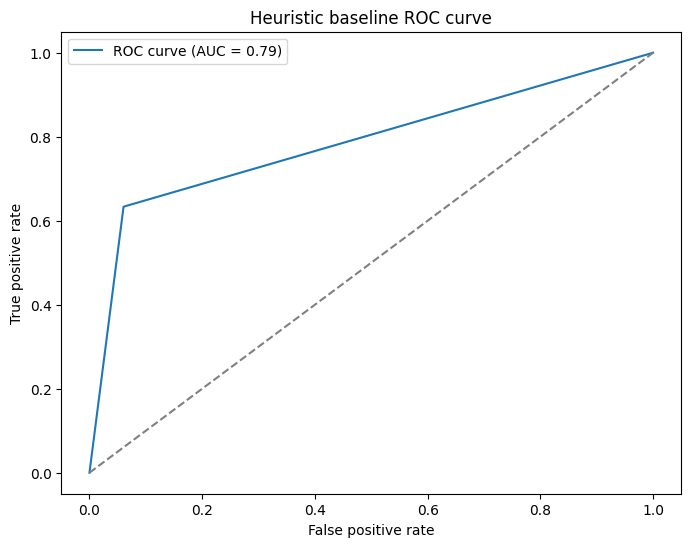

In [17]:
# Predict the probabilities of the positive class on the test set.

x = pd.DataFrame()
x["podium_probability"] = np.where(race_quali_res_df["position_quali"] <= 3, perc_maintain_pod_leaky, 0)
x["podium_finish"] = race_quali_res_df["podium_finish"].reset_index(drop=True)

# Compute the ROC curve and the AUC score.
fpr, tpr, thresholds = roc_curve(x["podium_finish"], x["podium_probability"])
auc_score = roc_auc_score(x["podium_finish"], x["podium_probability"])
auc_value = auc(fpr, tpr)

# Plot the ROC curve and show the AUC score.
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('Heuristic baseline ROC curve')
plt.legend()
plt.show()

## Plugging the Leak

In [18]:
race_quali_res_df = pd.merge(
    left=race_quali_res_df, 
    right=race_df[["year", "raceId"]],
    how='left',
    left_on=["raceId"],
    right_on=["raceId"]
).rename({"year_x": "year"})

race_quali_res_df

,qualifyId,raceId,driverId,position_quali,position_race,kept_podium,podium_finish,year
0,1,18,1,1,1.0,True,True,2008
1,2,18,9,2,NaN,False,False,2008
2,3,18,5,3,5.0,False,False,2008
3,4,18,13,4,NaN,False,False,2008
4,5,18,2,5,2.0,False,True,2008
...,...,...,...,...,...,...,...,...
11031,11089,1171,860,18,22.0,False,False,2026
11032,11090,1171,815,19,17.0,False,False,2026
11033,11091,1171,822,20,19.0,False,False,2026
11034,11092,1171,4,21,18.0,False,False,2026


In [19]:
train, test = race_quali_res_df["year"] < 2024, race_quali_res_df["year"] >= 2024

train_set = race_quali_res_df[train]
test_set = race_quali_res_df[test]

In [20]:
top_quali = train_set[train_set["position_quali"] <= 3]

perc_maintain_pod = len(top_quali[top_quali["kept_podium"]]) / len(top_quali) 
f"{round(perc_maintain_pod * 100, 2)}%"

'62.7%'

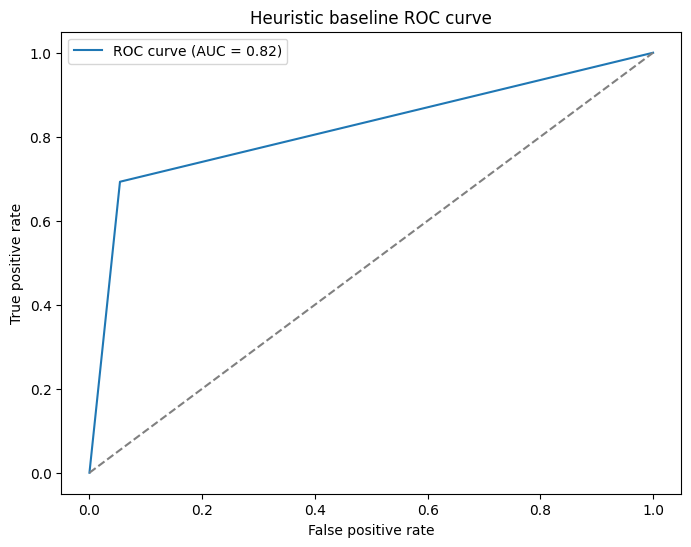

In [21]:
# Predict the probabilities of the positive class on the test set.
from sklearn.metrics import roc_auc_score, roc_curve, auc

test_set = test_set.reset_index(drop=True)

x = pd.DataFrame()
x["podium_probability"] = np.where(test_set["position_quali"] <= 3, perc_maintain_pod, 0)
x["podium_finish"] = test_set["podium_finish"].reset_index(drop=True)

# Compute the ROC curve and the AUC score.
fpr, tpr, thresholds = roc_curve(x["podium_finish"], x["podium_probability"])
auc_score = roc_auc_score(x["podium_finish"], x["podium_probability"])
auc_value = auc(fpr, tpr)

# Plot the ROC curve and show the AUC score.
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('Heuristic baseline ROC curve')
plt.legend()
plt.show()

## Fixing the Bad Model

We've still got an AUC of 0.97 which is close to perfect, one of the big problems that we seem to have is that because we're assigning a probability of 0 to non-podium starters that isn't realistic in real life (a 4 starter could easily become a 3rd place finish). Our model is severely overcorrecting for that meaning that our model *appears* to be completely correct but it isnt.

How can we fix this? Instead of assigning a probability of 0 that somone *not* on the podium will end up on the podium, we calculate the probability of someone not on the podium ending up on it and apply that instead of 0 instead. Yes, it's more likely that someone who starts 4th could be 3rd rather than 20th to 3rd but.

In [22]:
top_quali = train_set[train_set["position_quali"] > 3]
top_quali["obtained_podium"] = (top_quali["position_quali"].astype("Int64") > 3) & (top_quali["position_race"].astype("Int64") <= 3)
perc_obtain_pod = len(top_quali[top_quali["obtained_podium"]]) / len(top_quali)
perc_obtain_pod

/tmp/ipykernel_73495/2298790238.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_quali["obtained_podium"] = (top_quali["position_quali"].astype("Int64") > 3) & (top_quali["position_race"].astype("Int64") <= 3)


0.061127251597908196

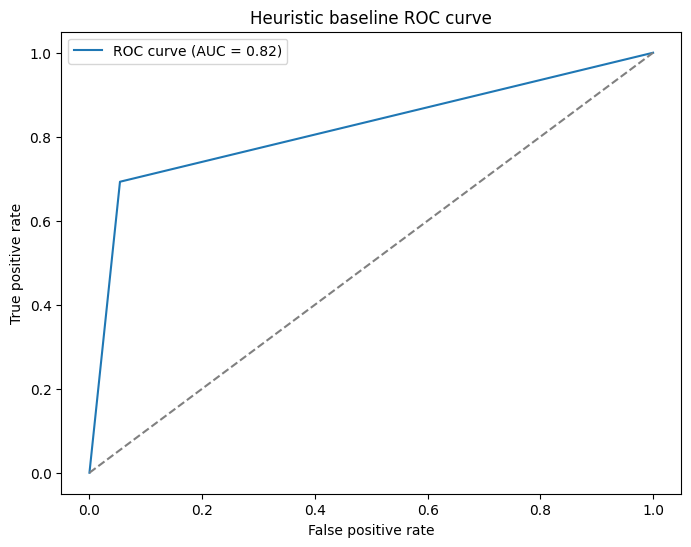

In [23]:
# Predict the probabilities of the positive class on the test set.
from sklearn.metrics import roc_auc_score, roc_curve, auc

test_set = test_set.reset_index(drop=True)

x = pd.DataFrame()
x["podium_probability"] = np.where(test_set["position_quali"] <= 3, perc_maintain_pod, perc_obtain_pod)
x["podium_finish"] = test_set["podium_finish"].reset_index(drop=True)

# Compute the ROC curve and the AUC score.
fpr, tpr, thresholds = roc_curve(x["podium_finish"], x["podium_probability"])
auc_score = roc_auc_score(x["podium_finish"], x["podium_probability"])
auc_value = auc(fpr, tpr)

# Plot the ROC curve and show the AUC score.
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('Heuristic baseline ROC curve')
plt.legend()
plt.show()

## Not Being Honest

There's a big problem with this however in that it's not entirely honest about the proabilities, this is because we're ignoring way too much information about the situation:
* A P1 starter is *very* likely to be in a podium finish bar something like an accident say, 87%
* A P4 starter could be quite likely to be in a podium finish because they only need to beat one driver say, 64%

At the minute, we're not taking into account position at all, everyone in a podium start gets 63% everyone else gets 8% which is causing the model to massively inflate and not measure something meaningful that we can improve - so we need a *per position heuristic instead*.

So, how we calculate this is we take every position on the grid, and see what are the proportion of times that they ended up in the podium spot.


In [24]:
# First, let's make a copy of the data to keep it separate
train_copy_1_df = train_set.copy()
test_copy_1_df = test_set.copy()

In [25]:
podium_probabilites = pd.DataFrame(train_copy_1_df.groupby(by="position_quali")["podium_finish"].mean()).rename(columns={"podium_finish":"podium_finish_probability"}).reset_index()
podium_probabilites

,position_quali,podium_finish_probability
0,1,0.759574
1,2,0.612766
2,3,0.508511
3,4,0.334043
4,5,0.23617
5,6,0.153191
6,7,0.097872
7,8,0.059574
8,9,0.044681
9,10,0.040426


Index(['qualifyId', 'raceId', 'driverId', 'position_quali', 'position_race',
       'kept_podium', 'podium_finish', 'year', 'podium_finish_probability'],
      dtype='object')


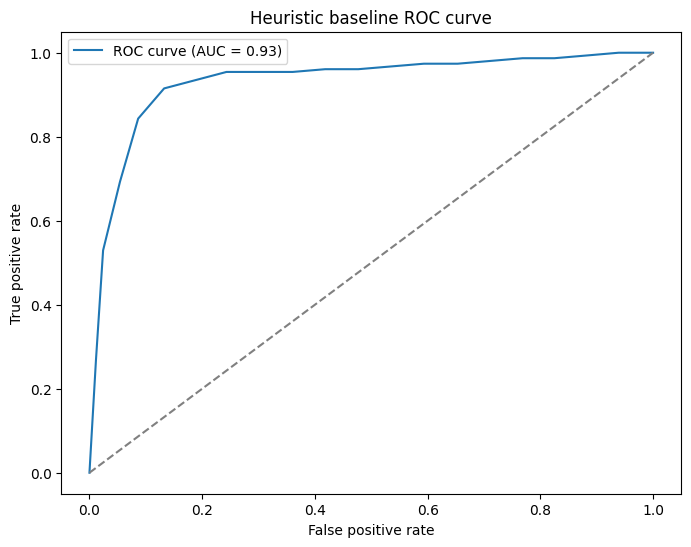

In [26]:
# Predict the probabilities of the positive class on the test set.
from sklearn.metrics import roc_auc_score, roc_curve, auc

test_copy_1_df = test_copy_1_df.reset_index(drop=True)

test_copy_1_df = pd.merge(
    left=test_copy_1_df, 
    right=podium_probabilites,
    how='left',
    left_on=["position_quali"],
    right_on=["position_quali"]
).rename(columns={"podium_finish_x": "podium_finish"})

print(test_copy_1_df.columns)

x = pd.DataFrame()
x["podium_probability"] = test_copy_1_df["podium_finish_probability"]
x["podium_finish"] = test_copy_1_df["podium_finish"].reset_index(drop=True)

# Compute the ROC curve and the AUC score.
fpr, tpr, thresholds = roc_curve(x["podium_finish"], x["podium_probability"])
auc_score = roc_auc_score(x["podium_finish"], x["podium_probability"])
auc_value = auc(fpr, tpr)

# Plot the ROC curve and show the AUC score.
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('Heuristic baseline ROC curve')
plt.legend()
plt.show()

AUC asks "are you ranking drivers in the right order?" — it doesn't care if you say 0.51 or 0.99 as long as the ranking is correct.
Brier Score asks "are your probabilities actually truthful?" — a model that says 0.87 when the real rate is 0.63 will get punished for that overconfidence, even if its rankings are perfect.
Together they cover different failure modes:

Good AUC, bad Brier Score → your model ranks well but is overconfident or underconfident in its probabilities
Bad AUC, good Brier Score → your probabilities are calibrated but you're ranking drivers in the wrong order
Good both → your model is both ranking correctly and producing honest probabilities

you compare each individual predicted probability to each individual actual outcome (0 or 1), not to the overall proportion.
So for each row in your test set:

* Take the predicted probability (e.g. 0.877 for a P1 starter)
* Take the actual outcome for that specific driver in that specific race (1 if they podiumed, 0 if they didn't)
* Square the difference

In [27]:

x = pd.DataFrame()
x["podium_probability"] = test_copy_1_df["podium_finish_probability"]
x["podium_finish"] = test_copy_1_df["podium_finish"].reset_index(drop=True)

# Compute the ROC curve and the AUC score.
brier_score_loss(x["podium_finish"], x["podium_probability"])

0.06509860383319616

So, in summary. Our naive model must be able to beat:
* Less than 0.065 for the brier score, meaning that the probabilities are more accurate
* Higher than 0.93 AUC for the ranking, meaning that we need to predict the podium finishers above the non-podium finishers more often